# California Housing - Linear Regression

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_openml
houses = fetch_openml(name="house_prices", as_frame=True).frame
houses

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
houses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
houses.shape

(1460, 81)

In [5]:
houses.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


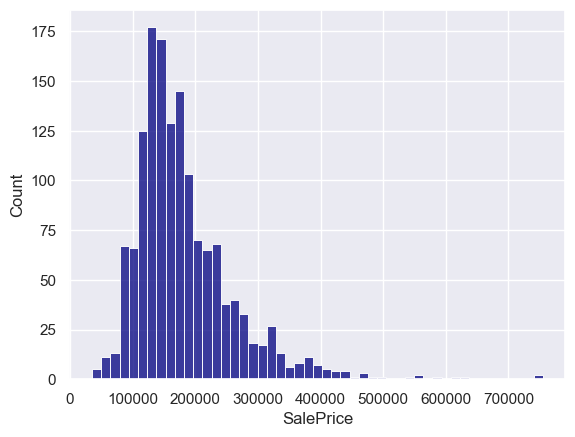

In [6]:
sns.set_theme()
sns.histplot(houses['SalePrice'], color='navy')
plt.show()

In [7]:
Q1 = houses['SalePrice'].quantile(0.25)
Q3 = houses['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
houses_filtered = houses[(houses['SalePrice'] >= lower_bound) & (houses['SalePrice'] <= upper_bound)]

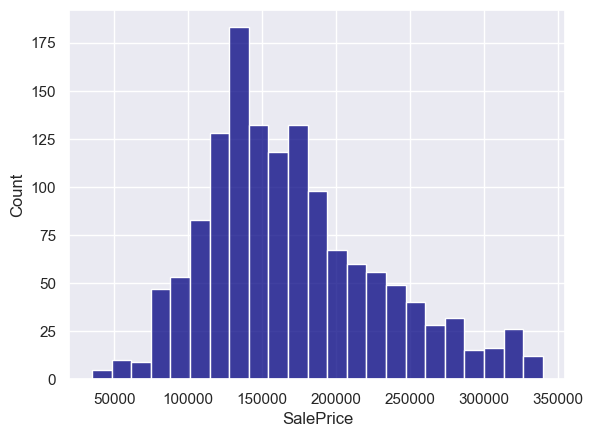

In [8]:
sns.set_theme()
sns.histplot(houses_filtered['SalePrice'], color='navy')
plt.show()

In [9]:
numeric_df = houses_filtered.select_dtypes(include=['float64', 'int64'])

In [10]:
numeric_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1399 entries, 0 to 1459
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1399 non-null   int64  
 1   MSSubClass     1399 non-null   int64  
 2   LotFrontage    1143 non-null   float64
 3   LotArea        1399 non-null   int64  
 4   OverallQual    1399 non-null   int64  
 5   OverallCond    1399 non-null   int64  
 6   YearBuilt      1399 non-null   int64  
 7   YearRemodAdd   1399 non-null   int64  
 8   MasVnrArea     1392 non-null   float64
 9   BsmtFinSF1     1399 non-null   int64  
 10  BsmtFinSF2     1399 non-null   int64  
 11  BsmtUnfSF      1399 non-null   int64  
 12  TotalBsmtSF    1399 non-null   int64  
 13  1stFlrSF       1399 non-null   int64  
 14  2ndFlrSF       1399 non-null   int64  
 15  LowQualFinSF   1399 non-null   int64  
 16  GrLivArea      1399 non-null   int64  
 17  BsmtFullBath   1399 non-null   int64  
 18  BsmtHalfBath 

In [11]:
numeric_df_cleaned = numeric_df.dropna()

In [12]:
# Features (all numeric columns except SalePrice)
X = numeric_df_cleaned.drop(columns=['SalePrice', 'Id'])

# Target (SalePrice)
y = numeric_df_cleaned['SalePrice']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

In [15]:
lm.fit(X_train, y_train)

LinearRegression()

In [16]:
print(lm.intercept_)

-301248.25556111516


In [17]:
lm.coef_

array([-1.34033369e+02,  9.22844902e+00,  3.56498711e-02,  1.58706325e+04,
        5.87150032e+03,  2.95145722e+02,  1.91946862e+02, -3.87670125e+00,
        1.55498278e+00,  3.37688975e+00,  2.89525661e-01,  5.22139819e+00,
        1.23164298e+01,  1.32539582e+01, -1.40084390e+01,  1.15619489e+01,
        1.29887722e+04, -2.79849877e+03,  7.79322534e+03,  6.45898437e+02,
       -8.38711913e+02, -1.51924905e+04,  2.99257290e+03,  8.21386445e+03,
        5.55793402e+00,  1.54012512e+04,  3.16418167e+00,  1.58942648e+01,
        2.28272208e+01, -2.62368544e+00,  1.53626596e+01,  5.46664708e+01,
       -1.98251747e+02,  7.64605202e+00,  2.92550382e+02, -3.59245372e+02])

In [18]:
cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coeff'])
cdf_sorted = cdf.sort_values(by='Coeff', ascending=False)
cdf_sorted

,Coeff
OverallQual,15870.632500
GarageCars,15401.251211
BsmtFullBath,12988.772164
Fireplaces,8213.864451
FullBath,7793.225340
OverallCond,5871.500317
TotRmsAbvGrd,2992.572896
HalfBath,645.898437
YearBuilt,295.145722
MoSold,292.550382


In [19]:
print("With all other features constant:\n")
for idx, val in cdf_sorted['Coeff'].items():
    
    bold_idx = f"\033[1m{idx}\033[0m"  # This makes idx bold in terminal output
    val_formatted = f"{val:.2f}"       # format val to 2 decimals

    if val < 0:
        print(f"A one-unit increase in {bold_idx} is associated with a decrease of ${val_formatted} in Price")
    elif val > 0:
        print(f"A one-unit increase in {bold_idx} is associated with an increase of ${val_formatted} in Price")
    else:
        print("Value had no effect at all")

With all other features constant:

A one-unit increase in OverallQual is associated with an increase of $15870.63 in Price
A one-unit increase in GarageCars is associated with an increase of $15401.25 in Price
A one-unit increase in BsmtFullBath is associated with an increase of $12988.77 in Price
A one-unit increase in Fireplaces is associated with an increase of $8213.86 in Price
A one-unit increase in FullBath is associated with an increase of $7793.23 in Price
A one-unit increase in OverallCond is associated with an increase of $5871.50 in Price
A one-unit increase in TotRmsAbvGrd is associated with an increase of $2992.57 in Price
A one-unit increase in HalfBath is associated with an increase of $645.90 in Price
A one-unit increase in YearBuilt is associated with an increase of $295.15 in Price
A one-unit increase in MoSold is associated with an increase of $292.55 in Price
A one-unit increase in YearRemodAdd is associated with an increase of $191.95 in Price
A one-unit increase i

In [20]:
predictions = lm.predict(X_test)

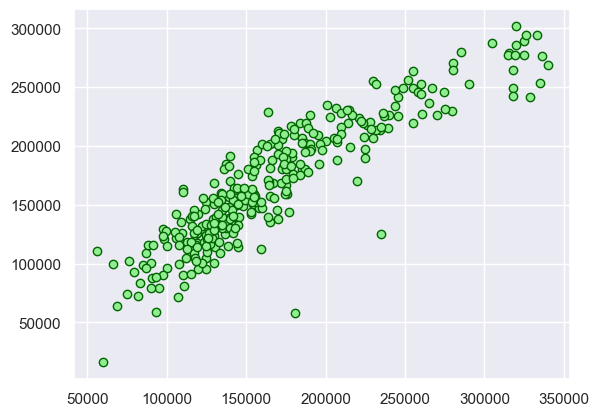

In [21]:
plt.scatter(y_test, predictions, edgecolors='darkgreen', c='lightgreen')
plt.show()

In [22]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
corr = np.corrcoef(y_test, predictions)[0, 1]

print(f"R-squared: {r2:.3f}")
print(f"Pearson correlation: {corr:.3f}")
print(f"Initial results from the R-squared value suggest the model explains about {r2 * 100:.2f}% of the variance in the target variable")

R-squared: 0.818
Pearson correlation: 0.905
Initial results from the R-squared value suggest the model explains about 81.83% of the variance in the target variable


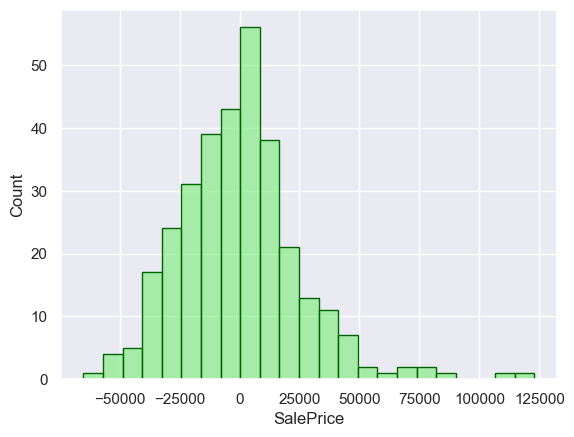

In [23]:
sns.histplot((y_test-predictions), edgecolors='darkgreen', color='lightgreen')
plt.show()

In [24]:
from sklearn import metrics

In [25]:
MAE = metrics.mean_absolute_error(y_test, predictions)
MSE = metrics.mean_squared_error(y_test, predictions)
RMSE = np.sqrt(metrics.mean_squared_error(y_test, predictions))

In [26]:
print(f"MAE: {MAE}\nMSE: {MSE}\nRMSE: {RMSE}")

MAE: 18896.818694329962
MSE: 648706888.7361864
RMSE: 25469.724944258553


Interpretting Evaluation Metrics
* MAE: On average, our model’s predictions are off by about \\$18896.81 (or whatever unit our target variable uses)
* MSE: Because the errors are squared, large mistakes get punished much more heavily. This metric is more sensitive to outliers
* RMSE: On average, our predictions are off by about \\$25469.72, but larger errors have more weight compared to MAE